In [5]:
!pip install sentence-transformers

In [15]:
import pandas as pd
from sentence_transformers import SentenceTransformer
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

In [7]:
sentences = [
    # Cricket
    "The batsman scored a century in the match",
    "The bowler took five wickets in the game",
    "The team won the match by chasing a huge target",
    "Fielding plays a crucial role in cricket matches",
    #Cooking
    "The chef prepared a delicious pasta dish",
    "Baking requires precise measurements of ingredients",
    "Grilling vegetables enhances their flavor",
    #Cybersecurity
    "Strong passwords are essential for online security",
    "Phishing attacks trick users into revealing information",
    "Firewalls help protect networks from unauthorized access"]

In [8]:
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [12]:
similarity_matrix = cosine_similarity(embeddings)

print("Similarity Matrix Shape:", similarity_matrix.shape)

Similarity Matrix Shape: (10, 10)


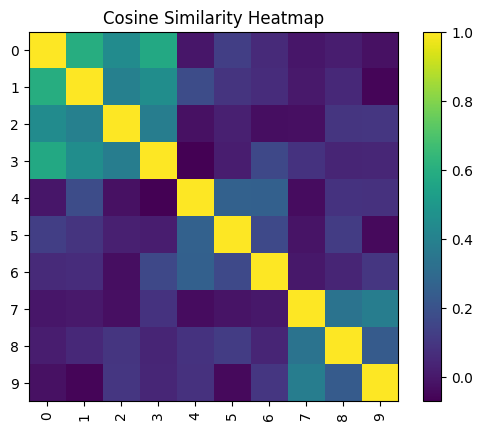

In [13]:
plt.figure()
plt.imshow(similarity_matrix)
plt.colorbar()
plt.title("Cosine Similarity Heatmap")
plt.xticks(range(len(sentences)), range(len(sentences)), rotation=90)
plt.yticks(range(len(sentences)), range(len(sentences)))
plt.show()

In [17]:
import numpy as np

query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])

similarities = cosine_similarity(query_embedding, embeddings)[0]

# Get top 2 most similar sentences
top_indices = np.argsort(similarities)[-2:][::-1]

print("Query:", query)
print("\nTop 2 similar sentences:\n")

for idx in top_indices:
    print(f"Sentence: {sentences[idx]}")
    print(f"Similarity Score: {similarities[idx]:.4f}\n")

Query: The bowler took three wickets in one over

Top 2 similar sentences:

Sentence: The bowler took five wickets in the game
Similarity Score: 0.8470

Sentence: The batsman scored a century in the match
Similarity Score: 0.5682

